参数高效微调

In [1]:
#sst2就是情感分类的数据集，二分类的
!ls sst2

README.md  data


#阿里云运行本代码时，上面的内容可以删掉，直接把sst2文件夹和jupyter代码文件放在同一个路径

In [3]:
!pip list|grep datasets

datasets                       2.20.0


In [4]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoConfig, AutoModel, get_cosine_schedule_with_warmup

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from tqdm.auto import tqdm

# 固定seed
torch.manual_seed(42)
# 确定设备：如果有GPU可用则使用GPU，否则使用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#如果GPU可以，可以改为20
num_epochs = 5
patience = 5

training_record = {}

## preparation

SST-2（Stanford Sentiment Treebank）是斯坦福大学发布的一个用于情感分析的数据集，旨在对句子的情感进行分类。该数据集中包含电影评论句子，每个句子都带有相应的情感标签。情感标签分为两类：正面（positive）和负面（negative），因此 SST-2 是一个二分类任务的数据集。

Positive（正面）：

"The movie was absolutely fantastic."（这部电影绝对太棒了。）
"I loved the acting and the storyline."（我喜欢演技和故事情节。）

Negative（负面）：

"The film was a complete disaster."（这部电影完全是个灾难。）
"The acting was terrible, I wouldn't recommend it."（演技糟糕，我不推荐这部电影。）

### load dataset

In [15]:
# https://huggingface.co/google-bert/bert-base-uncased

# 加载BERT的分词器（tokenizer），uncased 表示不区分大小写
tokenizer = AutoTokenizer.from_pretrained("/root/bert-base-uncased")

# 加载本地SST-2情感分类数据集，文件格式为parquet
# 数据集分为训练集和验证集
dataset_sst2 = load_dataset(
    "parquet",  # 指定文件格式
    data_files={
        "train": "./sst2/data/train-00000-of-00001.parquet",           # 训练集文件路径
        "validation": "./sst2/data/validation-00000-of-00001.parquet"  # 验证集文件路径
    }
)

# 定义用于DataLoader的自定义collate_fn函数，将原始batch加工为模型输入
def collate_fn(batch):
    # 提取batch中的句子字符串，组成一个列表
    sentences = [x["sentence"] for x in batch]
    # 使用tokenizer对句子进行分词编码
    # padding="longest"：对batch中句子按最长句子对齐补零
    # truncation=True：如句子超长则截断
    # return_tensors="pt"：输出为PyTorch tensor
    # max_length=512：最长支持到512个token
    inputs = tokenizer(
        sentences, 
        padding="longest", 
        truncation=True, 
        return_tensors="pt", 
        max_length=512
    )
    # 提取标签，转换为long类型的Tensor
    labels = torch.tensor([x["label"] for x in batch])
    # 返回模型直接可用的inputs字典和labels
    return inputs, labels

# 构建训练集的DataLoader
# batch_size=32，每个batch 32条数据
# shuffle=True，训练时打乱顺序
# 使用自定义collate_fn
train_loader = DataLoader(
    dataset_sst2["train"], 
    batch_size=32, 
    shuffle=True, 
    collate_fn=collate_fn
)
# 构建验证集的DataLoader
# batch_size=32
# 不需要shuffle
val_loader = DataLoader(
    dataset_sst2["validation"], 
    batch_size=32, 
    collate_fn=collate_fn
)


In [6]:
len(dataset_sst2["train"])

67349

In [7]:
# 遍历 DataLoader 中的一个批次示例（用于查看每个批次的数据结构和内容）
for inputs, label in train_loader:
    # 打印当前 batch 第0个样本的 input_ids（即分词后的token id序列）
    print(inputs['input_ids'][0])
    # 打印当前 batch 第1个样本的 input_ids
    print(inputs['input_ids'][1])
    # 打印 attention_mask 的形状
    # 说明:
    #   - 这里的形状为 (32, 33)
    #   - 第一个维度 32 表示 batch_size 为32，每批有32条样本
    #   - 第二个维度 33 表示本批次里最长的句子分成了33个token（含[CLS]/[SEP]等特殊标记）
    #   - DataLoader 通过 collate_fn（padding="longest"）把所有句子都pad到了本批次最长的句子长度（33）
    #   - 这样，所有 input_ids、attention_mask、token_type_ids 形状都一样，便于张量运算
    print(inputs['attention_mask'].shape)
    
    print(inputs['attention_mask'][0])  # 打印第0个样本的 attention_mask 实际值
    # 答疑：BERT/BERT-like 模型中，这里的 attention_mask 通常只有 padding mask，
    # 即：1 代表 real token，0 代表 padding（非真实token）。
    # 主要作用：让模型在自注意力/编码阶段“忽略”被 pad 的那些位置，不影响句子真实表达。
    # 一般来说，除了 padding，attention_mask 不包含其它 mask（比如 causal mask），
    # 因为 BERT 是双向注意力，不像 GPT 需要未来 masked。
    print(inputs['token_type_ids'][0])  # 打印第0个样本的token_type_ids
    print(label)  # 打印当前 batch 的标签张量
    break  # 只查看第一个batch，避免输出过多

tensor([ 101, 2062, 8669, 1010, 2062, 6832,  102,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0])
tensor([  101,  2009,  1005,  1055, 10889, 11519,  1010,  3391,  2005,  1037,
         7891, 18932,  1999,  1037,  2186,  1012,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0])
torch.Size([32, 33])
tensor([1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor([1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 1])


### define evaluattion and training function

In [9]:
# # 这行代码的作用是将当前虚拟环境中已安装的所有Python包及其版本号输出到requirement.txt文件中
# # 这样可以方便后续复现环境，或在其它地方通过 pip install -r requirement.txt 一次性安装相同依赖
# !pip freeze >requirement.txt

In [ ]:
def evaluate(model, val_loader):
    """
    评估模型在验证集上的性能，返回验证集损失和准确率。

    参数:
    model: 被评估的模型（应支持以输入张量字典作为参数进行forward调用）
    val_loader: 验证集 DataLoader，输出 (batch_inputs, batch_labels)

    返回:
    val_loss: 验证集平均损失
    val_acc: 验证集平均准确率
    """
    model.eval()  # 切换为评估模式（影响 Dropout/BatchNorm 等层的行为）
    val_loss = 0  # 累加验证集损失
    val_acc = 0   # 累加正确预测的样本数量
    # 评估时关闭梯度计算以节省显存、加快推理
    with torch.no_grad():
        total_samples = 0  # 统计本轮评估总样本数
        for inputs, labels in val_loader:
            # 将所有输入 tensor 和标签移动到目标设备（如 cuda 或 cpu）
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.to(device)
            # 前向传播，获得类别为 1 的预测概率，通常 shape: (batch_size,)
            
            # 这里inputs是一个dict，key为模型需要的输入参数（比如'input_ids', 'attention_mask', 'token_type_ids'等），value为每个参数对应的tensor
            # model(**inputs)等价于 model(input_ids=..., attention_mask=..., token_type_ids=...) 这样将dict自动拆成关键字参数传入模型
            # 这种写法是transformers模型推荐的批量输入方式，可以自动与模型的forward参数匹配，简便且易维护
            probs = model(**inputs)
            # 计算二分类交叉熵损失，labels 需为 float 类型
            # 对 batch 内样本自动求平均
            loss = F.binary_cross_entropy(probs, labels.float())
            val_loss += loss.item()  # 累加当前 batch 损失
            # 统计准确率：概率大于 0.5 视为正类，与实际标签进行比对
            val_acc += ((probs > 0.5) == labels).sum().item()
            total_samples += len(labels)  # 累加当前 batch 样本数量

    # 平均损失：累加损失除以 batch 数
    val_loss /= len(val_loader)
    # 平均准确率：累计预测正确样本数除以总样本数
    val_acc /= total_samples
    return val_loss, val_acc


def train(model, train_loader, val_loader, device, num_epochs=3, patience=3):
    """
    完整的模型训练+评估主循环，包含早停机制与训练过程记录。

    参数:
    model: 被训练的PyTorch模型
    train_loader: 训练集 DataLoader
    val_loader: 验证集 DataLoader
    device: 计算设备（'cuda'或'cpu'）
    num_epochs: 最多训练轮数
    patience: 连续多少轮val_acc未提升则早停

    返回:
    history: dict，记录每一轮的train/val损失及准确率
    """
    model.to(device)  # 将模型权重参数送到目标device

    # 优化器，AdamW比Adam更适合transformers，支持去耦权重衰减
    # AdamW（Adam with Weight Decay Fix）优化器的核心思想、公式原理如下：
    # ---
    # 1. 常规Adam优化的权重更新公式是：
    #    m_t = β1 * m_{t-1} + (1 - β1) * g_t      # 一阶矩动量（均值，动量）
    #    v_t = β2 * v_{t-1} + (1 - β2) * g_t^2    # 二阶矩动量（方差）
    #    m_hat = m_t / (1 - β1^t)                 # 偏置校正
    #    v_hat = v_t / (1 - β2^t)
    #    θ_{t+1} = θ_t - α * m_hat / (sqrt(v_hat) + ϵ)
    #    其中 θ 表示参数, g 为当前梯度, α为学习率。
    # 
    # 2. 传统做法（如L2正则/L2 weight decay）会在损失函数里对θ加惩罚项，或者直接把weight decay项加入每步的梯度中，
    #    但这会和自适应矩估计相混杂，从理论和实际都不太理想。
    # 
    # 3. AdamW提出：正则项（weight decay）应直接作用在参数上、与梯度分离，即
    #    θ_{t+1} = θ_t - α * (m_hat / (sqrt(v_hat) + ϵ) + λ * θ_t)
    #    其中λ为weight decay系数。
    #    在实际AdamW实现中，参数更新顺序是先按Adam的自适应步长算"主要更新", 然后参数整体再额外* (1 - α * λ)
    #    这样权重衰减只由超参数控制、不会被m/v自适应缩放干扰，能更有效收敛，泛化更好。
    #
    # 4. 总结：
    #    - AdamW的weight decay不是对梯度做L2正则，而是对参数直接衰减
    #    - 理解为θ = θ - α * (...adam...) - α*λ*θ
    #    - PyTorch实现细节：官网见 https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

    # 计算训练过程中总的step数（1 step = 1 minibatch）
    total_steps = num_epochs * len(train_loader)

    # 创建余弦退火+warmup的调度器（适应transformers等大模型训练习惯）

    # 这里的scheduler是HuggingFace transformers库中常用的余弦退火带Warmup（预热）的学习率（learning rate）调度器
    # get_cosine_schedule_with_warmup的核心思想是——
    #   1. 训练开始的前num_warmup_steps步，学习率从0线性上升到初始最大值
    #   2. 剩余(num_training_steps - num_warmup_steps)步，学习率按余弦函数从最大值逐渐退火减小到0
    #   这样可以减少训练初期因大学习率震荡，同时后期收敛更平滑
    
    # 其数学表达式如下（设step为当前step，num_warmup_steps为预热步数，num_training_steps为总步数）：
    #   - 若 step < num_warmup_steps:
    #       lr = base_lr * step / num_warmup_steps
    #   - 若 step >= num_warmup_steps:
    #       lr = base_lr * 0.5 * (1 + cos(pi * (step - num_warmup_steps) / (num_training_steps - num_warmup_steps)))
    #   其中base_lr是optimizer初始设定的最大学习率
    
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.2 * total_steps),  # 预热阶段步数=总步数20%，即前20%步数线性升温
        num_training_steps=total_steps           # 总训练步数，后续阶段逐步退火
    )

    # early stopping相关变量
    best_val_acc = -1  # 记录最佳val_acc
    cur = 0            # 没有提升的epoch计数器

    # 训练过程记录字典
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()  # 切换为训练模式
        train_loss = 0   # 当前epoch累计损失
        train_acc = 0    # 当前epoch累计准确数
        total_samples = 0  # 当前epoch累计样本数

        # 批量遍历训练集
        for inputs, labels in tqdm(train_loader):
            # 数据搬运到device
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.to(device)

            # 梯度归零（每次优化前都要）
            optimizer.zero_grad()
            # 前向传播计算输出概率
            probs = model(**inputs)  # 字典解包
            # 计算二分类交叉熵损失
            # 二分类交叉熵损失的计算过程如下：
            # 假设probs是模型对每个样本预测为正类（标签为1）的概率，labels是每个样本的真实标签（0或1）。
            # 对每个样本，损失= -[y*log(p) + (1-y)*log(1-p)]，其中y为标签，p为预测概率。
            # F.binary_cross_entropy 会自动对一个batch里的所有样本求平均，返回这个batch的平均损失。
            loss = F.binary_cross_entropy(probs, labels.float())
            # 反向传播计算梯度
            loss.backward()
            # 参数更新
            optimizer.step()
            # 调度器调整学习率
            scheduler.step()

            # 记录训练损失
            train_loss += loss.item()
            # 记录本batch中预测正确的样本数量
            train_acc += ((probs > 0.5) == labels).sum().item()
            total_samples += len(labels)

        # 每个epoch的train loss,train acc平均
        train_loss /= len(train_loader)
        train_acc  /= total_samples

        # 评估本epoch模型在验证集（不启用梯度）表现
        val_loss, val_acc = evaluate(model, val_loader)

        # 记录训练与验证过程指标并print
        print(f"epoch {epoch}: train_loss {train_loss:.4f}, train_acc {train_acc:.4f}, val_loss {val_loss:.4f}, val_acc {val_acc:.4f}")
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Early Stopping：如果有提升则刷新最佳acc，否则cur+1
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            cur = 0
        else:
            cur += 1
        # 若patience次连续无提升，则提前终止训练
        if cur >= patience:
            print("提前停止训练")
            break

    return history

### a function to check the parameters that could be fintuned

In [11]:
def human_readable_count(n):
    """
    将数字 n 转换为更可读的格式：xxx、xxxK、xxxM、xxxB。
    例如：
      1500 -> 1.50K
      2_300_000 -> 2.30M
      1_700_000_000 -> 1.70B
    参数:
        n (int): 需要格式化的数字
    返回:
        str: 可读性更强的字符串表示
    """
    if n < 1_000:
        # 小于1千，直接输出原数
        return f"{n}"
    elif n < 1_000_000:
        # 千到百万之间，保留两位小数，以K(千)为单位
        return f"{n/1_000:.2f}K"
    elif n < 1_000_000_000:
        # 百万到十亿之间，保留两位小数，以M(百万)为单位
        return f"{n/1_000_000:.2f}M"
    else:
        # 大于十亿，保留两位小数，以B(十亿)为单位
        return f"{n/1_000_000_000:.2f}B"

def count_parameters(model):
    """
    统计并打印模型的参数总数、可训练参数数、冻结参数数及比例。
    参数:
        model (nn.Module): 需要统计参数的PyTorch模型
    """
    # 计算模型参数总数
    total_params = sum(p.numel() for p in model.parameters())
    # 计算模型中可训练（需要梯度）参数数量
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    # 计算模型冻结（不需要梯度）参数数量
    frozen_params = total_params - trainable_params

    # 打印模型参数总数，并用human_readable_count格式化输出
    print(f"Total Parameters:\t{human_readable_count(total_params):>8}")  # 总参数数量
    # 打印冻结参数数量
    print(f"Frozen Parameters:\t{human_readable_count(frozen_params):>8}")  # 冻结参数数量
    # 打印可训练参数数量，以及所占总参数的百分比
    print(f"Trainable Parameters:\t{human_readable_count(trainable_params):>8}\t{trainable_params / total_params:.2%}")  # 可训练参数数量及比例

In [12]:
import matplotlib.pyplot as plt  # 导入用于绘图的matplotlib库

def plot_training_record(training_record, metric_name="val_acc"):
    """
    绘制训练过程中的某项性能指标变化曲线

    参数:
        training_record (dict): 包含训练记录的字典。每个键为方法名称（如"Frozen"），每个值为记录的字典（包含'metric_name'对应的数值列表）。
        metric_name (str): 指定要绘制的性能指标名称，默认为"val_acc"（验证集准确率）。

    返回:
        无（直接展示图表）
    """
    plt.figure(figsize=(12, 6))  # 创建一个大小为12x6英寸的绘图窗口
    # 遍历每个方法的训练记录，对每个方法分别生成一条折线
    for method_name, record in training_record.items():  # method_name是方法名称（如Frozen），record是其对应的指标记录字典
        metrics = record[metric_name]  # 取出该方法下metric_name的所有数值（如所有轮次的val_acc）
        plt.plot(range(len(metrics)), metrics, label=method_name)  # 画出x为轮次（epoch），y为metric数值的折线，并设置图例

    plt.xlabel("Epoch")  # 设置横轴标签为"Epoch"（训练轮次）
    plt.ylabel("Validation Accuracy")  # 设置纵轴标签，此处假定metric_name是val_acc，可自定义
    plt.legend()  # 显示不同方法的图例，便于辨识
    plt.grid()  # 启用网格线，使图表更易于阅读
    plt.show()  # 展示图表窗口

In [14]:
#bert-base-uncased的uncased不区分大小写的意思
bert_model=AutoModel.from_pretrained("/root/bert-base-uncased")
print(bert_model)

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

## A Frozen pretrained Bert as a feature extractor  将预训练过的Bert冻结作为特征提取器

In [17]:
# https://huggingface.co/docs/transformers/model_doc/bert 官网帮助
# 定义一个FrozenBert类，继承自nn.Module，实现“特征提取器”模式，只训练最后的分类头
class FrozenBert(nn.Module):
    def __init__(self):
        super().__init__()
        # 加载预训练的BERT模型（不区分大小写的英文文本，from_pretrained会自动下载并缓存模型参数）
        self.model = AutoModel.from_pretrained("/root/bert-base-uncased")

        # BERT输出的隐藏状态（特征向量）的维度，通过config.hidden_size获取，通常为768
        # 分类头：一个线性层，将BERT的[CLS]特征映射到单一的输出节点，通常用于二分类任务
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 将BERT模型的所有参数冻结，使其在训练中不被优化，只训练classifier层
        for param in self.model.parameters():
            param.requires_grad = False  # requires_grad设为False即代表参数不会参与反向传播更新

    def forward(self, **inputs):
        """
        前向传播逻辑：
        输入：已经经过tokenizer编码的数据（包含input_ids, attention_mask等，通过**inputs字典展开）
        1. 通过BERT主干模型获得隐层表示（last_hidden_state），shape为(batch_size, seq_len, hidden_dim)
        2. 只选取[CLS] token对应的特征（序列第一个token的隐藏状态，通常用于句子级别的分类任务）
        3. 将[CLS]特征输入分类器得到logits，shape为(batch_size, 1)
        4. 用sigmoid将logits转换为概率，最后用squeeze去除不必要的维度（比如将(batch_size, 1)变成(batch_size,)）
        """
        feature = self.model(**inputs).last_hidden_state[:, 0, :]  # 只取[CLS]位置的特征 (batch, hidden_dim)
        logits = self.classifier(feature)                          # 全连接分类头，输出logits (batch, 1)
        return torch.sigmoid(logits).squeeze()                     # Sigmoid概率，去除多余维度

# 实例化FrozenBert，模型结构如上，只训练最后一层分类头
frozen_bert = FrozenBert()
print(frozen_bert)

# （可选）遍历所有参数并打印其形状，帮助检查每个层的参数量
for name, param in frozen_bert.named_parameters():
    print(name, param.shape)

# 统计模型参数数量（需要提前定义count_parameters函数）
count_parameters(frozen_bert)

# training_record是用于记录不同训练阶段性能（比如val_acc、val_loss等变化）的字典对象，在前文有初始化


FrozenBert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

In [19]:
# !ls /root/.cache/huggingface/hub/models--bert-base-uncased/

In [20]:
# 调用train函数来训练冻结BERT模型（FrozenBert），只优化最后的分类器层
# 参数说明：
#   frozen_bert     ： 前面定义并实例化的FrozenBert模型对象（BERT主干参数全部冻结，仅分类头可训练）
#   train_loader    ： 训练集的数据加载器，按批次迭代提供训练数据
#   val_loader      ： 验证集的数据加载器，用于训练过程中评估模型性能
#   device          ： 当前训练所使用的设备（如'cuda'或'cpu'）
#   num_epochs      ： 训练迭代总轮数，指定模型最多训练多少次整个训练集
#   patience        ： 早停策略的耐心轮数，若验证集指标多轮未提升则提前停止训练
# 返回值：
#   训练记录（通常是包含训练和验证准确率/损失随epoch变化的字典），并保存在training_record["Frozen"]键下
training_record["Frozen"] = train(
    frozen_bert,       # 冻结BERT主干，仅训练分类头的模型
    train_loader,      # 训练数据加载器
    val_loader,        # 验证数据加载器
    device,            # 运行设备（CPU/GPU）
    num_epochs=num_epochs,  # 最大训练轮数
    patience=patience       # 早停耐心
)

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6792, train_acc 0.5661, val_loss 0.6627, val_acc 0.5505


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.6447, train_acc 0.6216, val_loss 0.6154, val_acc 0.7110


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 2: train_loss 0.6149, train_acc 0.6914, val_loss 0.5868, val_acc 0.7741


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.5989, train_acc 0.7258, val_loss 0.5752, val_acc 0.7913


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.5947, train_acc 0.7323, val_loss 0.5733, val_acc 0.7913


In [21]:
training_record

{'Frozen': {'train_loss': [0.6791811715395604,
   0.6446934444321023,
   0.614916806549471,
   0.5988955221380021,
   0.5947349466224181],
  'train_acc': [0.5660663113038056,
   0.6216127930630002,
   0.691443080075428,
   0.7258311185021307,
   0.7323345558211704],
  'val_loss': [0.6626743503979274,
   0.6153572712625776,
   0.5868299028703144,
   0.5751719570585659,
   0.5732796511479786],
  'val_acc': [0.5504587155963303,
   0.7110091743119266,
   0.7740825688073395,
   0.7912844036697247,
   0.7912844036697247]}}

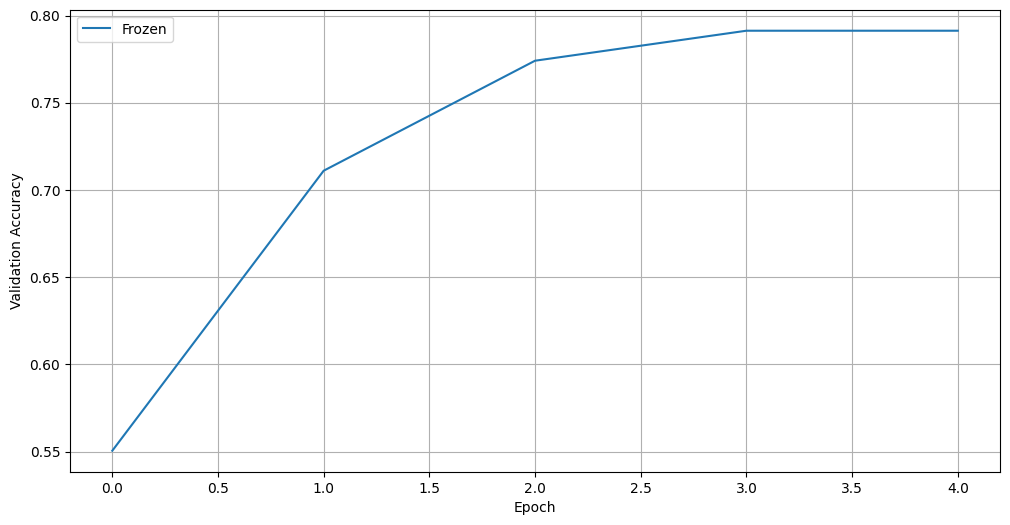

In [22]:
plot_training_record(training_record, metric_name="val_acc")

## Fully Finetuning

In [ ]:
class FullyFinetunedBert(nn.Module):
    """
    完全微调BERT模型类。
    该模型将整个BERT主干作为可训练参数，通过在[CLS]位置提取特征，
    并经过线性分类器后输出最终分类概率。
    """
    def __init__(self):
        super().__init__()
        # 加载指定路径下的预训练BERT模型，所有参数默认可训练
        self.model = AutoModel.from_pretrained("root/bert-base-uncased")  # 从本地/root/bert-base-uncased加载
        # 分类头，输入维度等于BERT的隐藏维（如768），输出为1（二分类）
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

    def forward(self, **inputs):
        # 前向传播，**inputs通常包含input_ids、attention_mask等
        # 调用BERT模型获取所有隐藏状态，last_hidden_state形状为(batch, seq_len, hidden_size)
        feature = self.model(**inputs).last_hidden_state[:, 0, :]  # 取[CLS]位向量，shape=(batch,hidden)
        # 通过分类器进行二分类，输出logits
        logits = self.classifier(feature)  # shape=(batch,1)
        # 使用sigmoid激活，将logits缩放到[0,1]概率，最后squeeze去除多余维度
        return torch.sigmoid(logits).squeeze()

# 实例化“完全微调”模型
fully_fine_tuned_bert = FullyFinetunedBert()

# 分隔线输出，使模型结构更清晰地打印
print('-'*50)
print(fully_fine_tuned_bert)
print('-'*50)

# 打印模型参数总数、可训练参数数；评估Fine-tune参数规模
count_parameters(fully_fine_tuned_bert)

# 训练完全微调模型，将所有参数纳入训练优化
training_record[" ully Fine-Tuning"] = train(
    fully_fine_tuned_bert,     # 需要训练的模型
    train_loader,              # 训练集数据加载器
    val_loader,                # 验证集数据加载器
    device,                    # 训练所用设备（GPU/CPU）
    num_epochs=num_epochs,     # 最大训练轮数
    patience=patience          # 早停耐心参数
)  # 训练过程将训练和验证指标记录到training_record字典

--------------------------------------------------
FullyFinetunedBert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
          

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.3029, train_acc 0.8611, val_loss 0.2339, val_acc 0.9071


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.1452, train_acc 0.9472, val_loss 0.2299, val_acc 0.9197


...

epoch 2: train_loss 0.0907, train_acc 0.9686, val_loss 0.2237, val_acc 0.9232


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.0605, train_acc 0.9799, val_loss 0.2550, val_acc 0.9220


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.0443, train_acc 0.9851, val_loss 0.2720, val_acc 0.9243


In [25]:
del fully_fine_tuned_bert

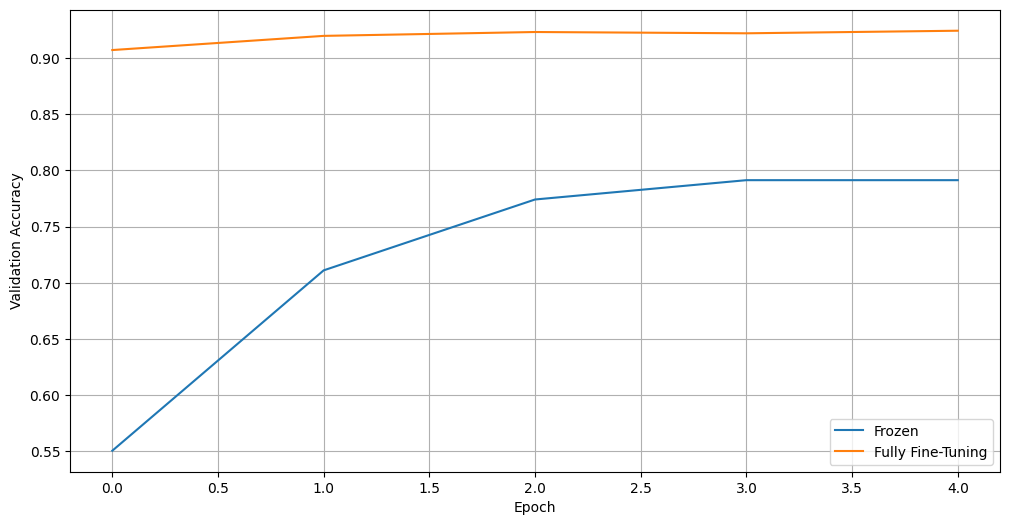

In [26]:
#可以看到全量微调的效果非常好
plot_training_record(training_record, metric_name="val_acc")

## BitFit

BitFit（论文：BitFit: Simple Parameter-efficient Fine-tuning or Transformer-based Masked Language-models）是一种稀疏的微调方法，它训练时只更新bias的参数或者部分bias参数。

In [ ]:
class BitFitBert(nn.Module):
    def __init__(self):
        super().__init__()
        # 加载预训练的BERT模型作为特征提取器（来自transformers的AutoModel）
        self.model = AutoModel.from_pretrained("/root/bert-base-uncased")
        # 定义一个线性分类器，将BERT输出的特征（hidden_size维）映射到1维（适合二分类任务）
        
        # self.model.config 是 transformers 包中模型的配置对象，包含了模型结构的参数等信息。
        # 这里通过 self.model.config.hidden_size 获取 BERT 输出特征的维度（即隐藏层大小），
        # 用来定义下游分类器输入的特征维数。如果直接 print(self.model.config) 也能看到很多结构或超参数信息。
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 冻结BERT模型中所有非偏置（bias）参数，只允许bias参数参与训练（即"BitFit"核心思想）
        for name, param in self.model.named_parameters():
            # 只有参数名中包含"bias"的参数允许梯度更新，其他参数保持冻结
            if "bias" not in name:
                param.requires_grad = False

    def forward(self, **inputs):
        # 前向传播部分
        # 传入输入数据，得到模型输出所有Token的隐藏状态（last_hidden_state形状：(batch, seq_len, hidden_size)）
        feature = self.model(**inputs).last_hidden_state[:, 0, :]  # 取第一个Token（CLS位）对应的向量作为句子表示
        logits = self.classifier(feature)  # 经过线 性分类器得到logits结果（形状：(batch, 1)）
        return torch.sigmoid(logits).squeeze()  # 使用Sigmoid激活转换为概率，并去掉多余的维度

# 实例化BitFit微调模型
bitfit_bert = BitFitBert()
print('-'*50)
# 打印模型结构，便于检查
print(bitfit_bert)
print('-'*50)
# 打印模型参数数量、参与训练的参数，体现BitFit高效性
count_parameters(bitfit_bert)

# 训练BitFit模型
# 训练过程中仅有部分bias参数和顶部分类器在更新，剩余参数完全冻结
# 训练过程记录在training_record["BitFit"]，便于后续效果对比、可视化等
training_record["BitFit"] = train(
    bitfit_bert,         # 微调的模型
    train_loader,        # 训练集Dataloader
    val_loader,          # 验证集Dataloader
    device,              # 运行设备（CPU/GPU）
    num_epochs=num_epochs,   # 最大训练轮数
    patience=patience        # 早停参数
)  

--------------------------------------------------
BitFitBert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (Lay

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6436, train_acc 0.6289, val_loss 0.4458, val_acc 0.8532


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.3690, train_acc 0.8541, val_loss 0.3300, val_acc 0.8681


...

epoch 2: train_loss 0.3324, train_acc 0.8634, val_loss 0.3151, val_acc 0.8727


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.3216, train_acc 0.8672, val_loss 0.3085, val_acc 0.8761


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.3202, train_acc 0.8661, val_loss 0.3081, val_acc 0.8750


In [28]:
del bitfit_bert

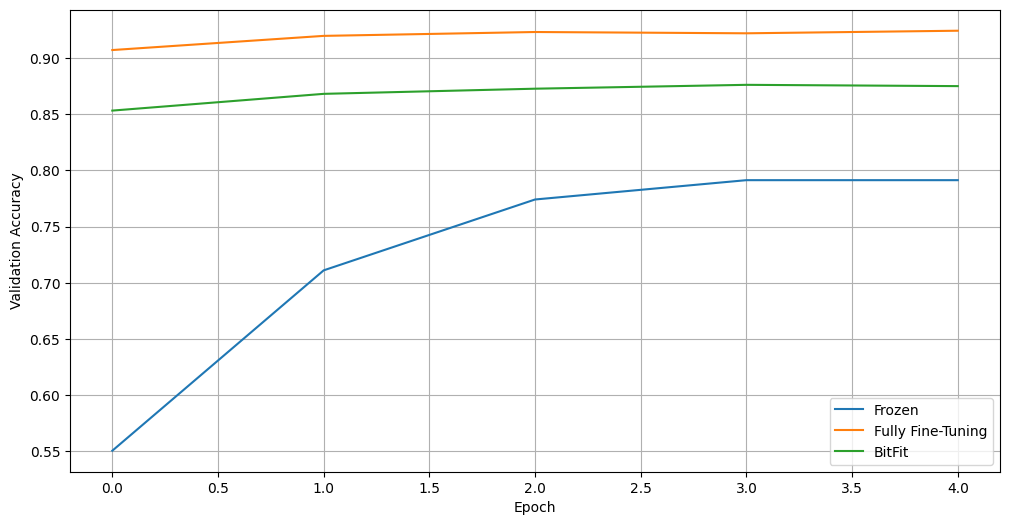

In [29]:
#偏置项冻结后效果变差了一些
plot_training_record(training_record, metric_name="val_acc")

## P-Tuning & P-Tuning v2 & Prefix Tuning

Prefix Tuning（论文：Prefix-Tuning: Optimizing Continuous Prompts for Generation），在输入token之前构造一段任务相关的virtual tokens作为Prefix，然后训练的时候只更新Prefix部分的参数，而PLM中的其他部分参数固定。

* 针对不同的模型结构，需要构造不同的Prefix。
    * 针对自回归架构模型：在句子前面添加前缀，得到 z = [PREFIX; x; y]，合适的上文能够在固定 LM 的情况下去引导生成下文（比如：GPT3的上下文学习）。
    * 针对编码器-解码器架构模型：Encoder和Decoder都增加了前缀，得到 z = [PREFIX; x; PREFIX0; y]。Encoder端增加前缀是为了引导输入部分的编码，Decoder 端增加前缀是为了引导后续token的生成。


P-Tuning（论文：GPT Understands, Too），该方法将Prompt转换为可以学习的Embedding层，并用MLP+LSTM的方式来对Prompt Embedding进行一层处理。

相比Prefix Tuning，P-Tuning加入的可微的virtual token，但仅限于输入层，没有在每一层都加；另外，virtual token的位置也不一定是前缀，插入的位置是可选的。这里的出发点实际是把传统人工设计模版中的真实token替换成可微的virtual token。

P-Tuning v2（论文： P-Tuning v2: Prompt Tuning Can Be Comparable to Fine-tuning Universally Across Scales and Tasks），该方法在每一层都加入了Prompts tokens作为输入，而不是仅仅加在输入层，这带来两个方面的好处：

更多可学习的参数（从P-tuning和Prompt Tuning的0.01%增加到0.1%-3%），同时也足够参数高效。
加入到更深层结构中的Prompt能给模型预测带来更直接的影响。


自然语言生成 (NLG) 和 自然语言理解 (NLU)
### 区别

|方法|参数重整化| 微调参数所在层 | 适配下游任务 |
|-|-|-|-|
|P-tuning|MLP + LSTM 或者 MLP| embedding 层| 使得GPT做NLU |
|P-tuning v2|不使用| 每一层 | NLG & NLU |
|prefix tuning|MLP| 每一层 | NLG |

In [30]:
import torch
import torch.nn as nn
prefix_tokens = nn.Parameter(torch.zeros(20, 768))
prefix_tokens = prefix_tokens.unsqueeze(0).expand(32, -1, -1) #给每个样本都增加一个（20, 768）
print(prefix_tokens.shape)

torch.Size([32, 20, 768])


In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel
import torch.nn.functional as F
import numpy as np

class PTuningBert(nn.Module):
    def __init__(self, num_virtual_tokens=20, reparameterization_type="MLP"):
        super().__init__()
        # 加载预训练BERT模型（采用AutoModel，同时指定模型路径）
        self.model = AutoModel.from_pretrained("/root/bert-base-uncased")
        # 分类器（单层线性，将BERT隐层维度投射为1，可用于二分类任务）
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 冻结除分类器外的所有bert参数，只让新加的模块进行训练
        for param in self.model.parameters():
            param.requires_grad = False

        hidden_size = self.model.config.hidden_size  # 获取隐藏层维度（通常为768）
        self.num_virtual_tokens = num_virtual_tokens  # 虚拟token的长度（即prompt长度）
        # 新增一个可学习参数作为虚拟token的embedding，初始为全0，
        # 后续训练过程中，这些embedding会被更新

        # 为什么要使用parameter
        # 在PyTorch中，nn.Parameter用于声明模型中可学习的参数（即需要通过梯度下降等优化方法进行更新的权重）。
        # 在P-tuning方法里我们要让prompt embedding可以被优化（更新），而不是固定不可学习的tensor，所以要用nn.Parameter。
        # 如果只是普通的tensor赋值，模型训练时不会自动计算和更新这些值。
        self.prompt = nn.Parameter(torch.zeros(self.num_virtual_tokens, hidden_size))
        print(self.prompt.shape)

        # 选择prompt的参数化方式，支持"MLP"和"LSTM"
        self.reparameterization_type = reparameterization_type
        if reparameterization_type == "MLP":
            # 用多层感知机对prompt做参数化&非线性处理，增强表达能力
            self.mlp_head = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, hidden_size),
                nn.ReLU(),
                nn.Linear(hidden_size, hidden_size),
            )
        elif reparameterization_type == "LSTM":
            # 用LSTM对prompt做建模，支持序列特征；双向两层
            self.lstm_head = nn.LSTM(
                input_size=hidden_size,
                hidden_size=hidden_size,
                num_layers=2,
                bidirectional=True,
                batch_first=True,
            )
            # LSTM输出进行MLP降维（因为是双向，隐藏态要*2）
            self.mlp_head = nn.Sequential(
                nn.Linear(hidden_size * 2, hidden_size * 2),
                nn.ReLU(),
                nn.Linear(hidden_size * 2, hidden_size),
            )

    def forward(self, input_ids, attention_mask, **args):
        # input_ids: [batch_size, seq_len]，batch中样本数
        batch_size = input_ids.size(0)
        # 扩展prompt参数，使其可以适配batch中的所有样本
        # 得到[batch_size, num_virtual_tokens, hidden_size]
        
        # 为什么是expand（， -1， -1）
        # 这里 self.prompt 的 shape 是 [num_virtual_tokens, hidden_size]，它表示 prompt embedding。
        # 为了能给 batch 里的每个样本都用同一组 prompt 参数，需要把 prompt 复制 batch_size 份：
        # self.prompt.unsqueeze(0) 后 shape: [1, num_virtual_tokens, hidden_size]
        # 调用 .expand(batch_size, -1, -1) 就会变成 [batch_size, num_virtual_tokens, hidden_size]，
        # 其中 -1 表示在该维度保持原始的 size，不做改变，只在 batch 维复制 batch_size 份。
        # 这样每个样本都能用到同样的 prompt
        prompt = self.prompt.unsqueeze(0).expand(batch_size, -1, -1)

        # 对虚拟token用自选模块（MLP/LSTM）进行处理，得到最终prompt
        if self.reparameterization_type == "MLP":
            # 维度不变：[batch_size, num_virtual_tokens, hidden_size]
            prompt = self.mlp_head(prompt)
        elif self.reparameterization_type == "LSTM":
            # LSTM编码，返回输出、状态，这里只使用输出
            prompt, _ = self.lstm_head(prompt)
            # 再接MLP降维到hidden_size
            prompt = self.mlp_head(prompt)

        # 获得原始输入的embedding输出 shape: [batch_size, seq_len, hidden_size]
        embedding_output = self.model.embeddings(input_ids)
        # 把prompt追加拼接到embedding前侧，形成新的输入
        # 形状: [batch_size, num_virtual_tokens+seq_len, hidden_size]
        extended_inputs_embeds = torch.cat([prompt, embedding_output], dim=1)
        # attention_mask也要同步调整，虚拟token对应的mask填充为1（可被注意）
        extended_attention_mask = torch.cat([
            torch.ones(batch_size, self.num_virtual_tokens).to(input_ids.device),  # [batch_size, num_virtual_tokens] 全1
            attention_mask   # [batch_size, seq_len]
        ], dim=1)  # [batch_size, num_virtual_tokens+seq_len]

        # 将处理后的embedding序列和注意力mask喂给BERT主干，输入是inputs_embeds
        outputs = self.model(inputs_embeds=extended_inputs_embeds, attention_mask=extended_attention_mask)
        # 完整序列的最后一层输出，shape: [batch_size, seq_len+num_virtual_tokens, hidden_size]
        # 获取去除虚拟token后第一个实际token的输出（对应原[CLS]）
        feature = outputs.last_hidden_state[:, self.num_virtual_tokens, :]
        # 分类器输出logit，然后用sigmoid归一化，适用于二分类
        logits = self.classifier(feature)
        return torch.sigmoid(logits).squeeze()

# 实例化p-tuning模型，自动采用MLP方式
ptuning_bert = PTuningBert()
# 也可以改为采用LSTM方式
# ptuning_bert = PTuningBert(reparameterization_type='LSTM')
print('-'*50)
print(ptuning_bert)
print('-'*50)

# 统计可训练参数量
# def count_parameters(model):
#     return sum(p.numel() for p in model.parameters() if p.requires_grad)
count_parameters(ptuning_bert)

torch.Size([20, 768])
--------------------------------------------------
PTuningBert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=T

In [32]:
for idx, (key, value) in enumerate(ptuning_bert.named_parameters()):
  print(f'key:{key}--value:{value.shape}')

key:prompt--value:torch.Size([20, 768])
key:model.embeddings.word_embeddings.weight--value:torch.Size([30522, 768])
key:model.embeddings.position_embeddings.weight--value:torch.Size([512, 768])
key:model.embeddings.token_type_embeddings.weight--value:torch.Size([2, 768])
key:model.embeddings.LayerNorm.weight--value:torch.Size([768])
key:model.embeddings.LayerNorm.bias--value:torch.Size([768])
key:model.encoder.layer.0.attention.self.query.weight--value:torch.Size([768, 768])
key:model.encoder.layer.0.attention.self.query.bias--value:torch.Size([768])
key:model.encoder.layer.0.attention.self.key.weight--value:torch.Size([768, 768])
key:model.encoder.layer.0.attention.self.key.bias--value:torch.Size([768])
key:model.encoder.layer.0.attention.self.value.weight--value:torch.Size([768, 768])
key:model.encoder.layer.0.attention.self.value.bias--value:torch.Size([768])
key:model.encoder.layer.0.attention.output.dense.weight--value:torch.Size([768, 768])
key:model.encoder.layer.0.attention.out

In [33]:
# 进行训练
training_record["P-Tuning"] = train(ptuning_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience)

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6761, train_acc 0.5738, val_loss 0.6283, val_acc 0.6388


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.5370, train_acc 0.7366, val_loss 0.4935, val_acc 0.7626


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 2: train_loss 0.4790, train_acc 0.7784, val_loss 0.4680, val_acc 0.7844


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.4504, train_acc 0.7974, val_loss 0.4471, val_acc 0.8005


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.4381, train_acc 0.8061, val_loss 0.4391, val_acc 0.8005


In [34]:
del ptuning_bert

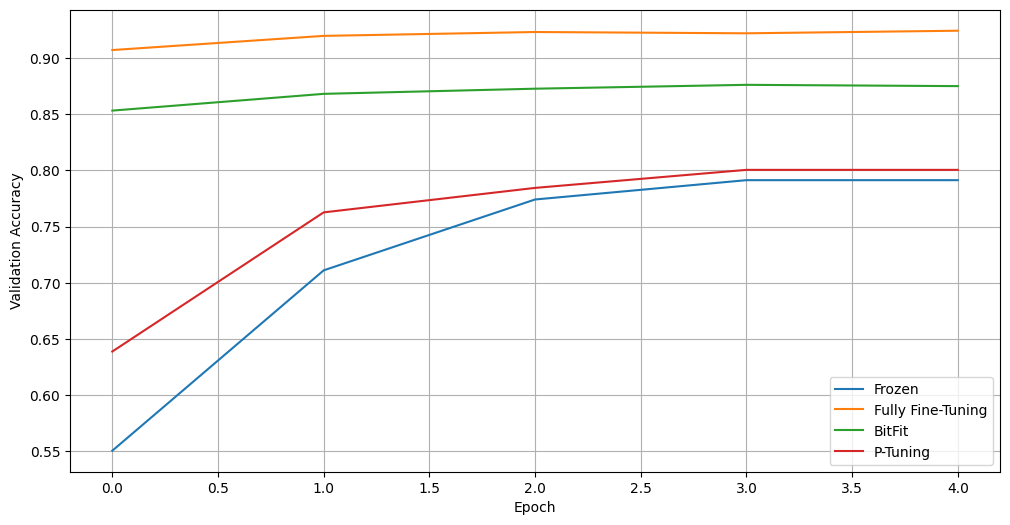

In [35]:
plot_training_record(training_record, metric_name="val_acc")

In [ ]:
# attention_mask 作用说明：
# 在BERT等Transformer模型中，attention_mask用于指示哪些输入token是“有效”的（即真实文本），哪些是padding或需要忽略的位置。
# 当attention_mask某个位置为1时，该位置被模型计算注意力；为0时，被mask（不计入注意力计算，也不会对输出产生影响）。
# 这样可以保证模型不会利用padding token或特殊token的信息，也能加速运算（不用关心被mask区域）。
# 例如输入[CLS] hello world [PAD] [PAD]，对应attention_mask=[1, 1, 1, 0, 0]，最后两位会被mask，不纳入模型特征学习。


# attention_mask 的运算过程举例如下：
import torch

# 假设有一个 batch_size=2，最大序列长度 max_seq_len=6 的输入
input_ids = torch.tensor([
    [101, 7592, 2088, 102,   0,   0],   # [CLS] hello world [SEP] [PAD] [PAD]
    [101, 2023, 2003, 1037, 2742, 102]  # [CLS] this is a test [SEP]
])

# attention_mask 要和 input_ids 形状一致，1 表示有效，0 表示需要 mask（如 PAD 位置）
attention_mask = (input_ids != 0).long()
print("input_ids:")
print(input_ids)
print("attention_mask:")
print(attention_mask)
# 输出：
# tensor([[1, 1, 1, 1, 0, 0],
#         [1, 1, 1, 1, 1, 1]])

# ————————————————————————————————————————
# attention_mask 与注意力(Attention)计算及softmax的先后顺序说明：

# 1. 首先模型得到每个token的Q(查询)、K(键)、V(值)向量
# 2. 计算原始注意力分数 (scores)：scores = Q @ K^T / sqrt(d_k)
# 3. 使用 attention_mask 把 padding 等无效位置的分数用一个极小的数（如 -1e9）替换
#    具体做法如下（以 PyTorch 为例）：
scores = torch.randn(2, 6, 6)  # 假设是 batch_size=2, 序列长=6 的attn score
# attention_mask unsqueeze(1) 变为 (batch, 1, seq_len) 用于broadcast
mask = attention_mask.unsqueeze(1)  # [2,1,6]
scores_masked = scores.masked_fill(mask == 0, float("-1e9"))

# 4. 然后对 masked scores 进行 softmax（在最后一个维度上）
attn_weights = torch.softmax(scores_masked, dim=-1)

# 5. 最后用加权和计算每个位置的输出
# output = attn_weights @ V

# 小结：
# attention_mask 先参与到注意力分数scores的mask，然后再softmax，最后再用于加权得到输出。

In [ ]:
# 定义一个用于BERT前缀微调（Prefix-Tuning）的nn.Module子类
class PrefixTuningBert(nn.Module):
    def __init__(self, num_virtual_tokens=20, prefix_projection=True):
        """
        参数: 
            num_virtual_tokens (int): 前缀虚拟token数量
            prefix_projection (bool): 是否对前缀token应用MLP投影
        """
        super().__init__()

        # 加载预训练BERT骨干网络（不包含pooler，仅输出最后一层特征）
        self.model = AutoModel.from_pretrained("root/bert-base-uncased")
        # 添加一个全连接层（用于二分类），将BERT输出变为一维
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 冻结BERT全部参数，只训练前缀相关参数和分类头
        for param in self.model.parameters():
            param.requires_grad = False

        # 初始化前缀相关参数
        self.num_virtual_tokens = num_virtual_tokens  # 虚拟前缀token数量
        self.prefix_projection = prefix_projection    # 是否启用MLP前缀映射
        hidden_size = self.model.config.hidden_size   # BERT隐藏层维度（如768）
        self.num_layers = self.model.config.num_hidden_layers  # BERT Transformer层数
        self.num_attention_heads = self.model.config.num_attention_heads  # 注意力头个数
        self.embed_size_per_head = hidden_size // self.num_attention_heads  # 每个头的维度
        
        # 说明：past_key_value含义
        # 1. 解码模式下保存历史key/value（如生成任务）
        # 2. 本例为前缀调优，将人工设计的prefix kv插入每层，实现prefix prompt trick

        # prefix-tuning的“投影”：把初始prefix embedding通过MLP投影到每层key/value空间
        # 输出shape为(num_layers, 2, hidden_size)，每层分别单独前缀化key和value
        if self.prefix_projection:
            # 初始化可训练前缀embedding，shape:[num_virtual_tokens, hidden_size]
            self.prefix_tokens = nn.Parameter(torch.zeros(self.num_virtual_tokens, hidden_size))
            # 两层MLP结构，将前缀投影到多层多头的key/value空间
            self.transform = torch.nn.Sequential(
                torch.nn.Linear(hidden_size, hidden_size),
                torch.nn.Tanh(),
                torch.nn.Linear(hidden_size, self.num_layers * 2 * hidden_size)
            )
        else:
            # 不使用投影，直接作为每层kv（效果通常较差）
            self.prefix_tokens = nn.Parameter(torch.zeros(self.num_virtual_tokens, hidden_size))

    def forward(self, input_ids, attention_mask, **args):
        """
        前向传播（将prefix前缀插入注意力kv缓存，以及拼接mask）

        参数:
            input_ids (Tensor): [batch_size, seq_len]
            attention_mask (Tensor): [batch_size, seq_len]
        返回:
            logits (Tensor): [batch_size]，每个样本的预测概率
        """
        batch_size = input_ids.size(0)

        # 扩展前缀tokens到batch
        prefix_tokens = self.prefix_tokens.unsqueeze(0).expand(batch_size, -1, -1)
        
        if self.prefix_projection:
            # MLP投影输出: [batch, num_virtual_tokens, num_layers*2*hidden_size]
            past_key_values = self.transform(prefix_tokens)
        else:
            # 不投影，直接用
            past_key_values = prefix_tokens

        # 1. reshape到: [batch, num_layers, 2, num_heads, num_virtual_tokens, head_dim]
        past_key_values = past_key_values.view(
            batch_size,
            self.num_layers,
            2,
            self.num_attention_heads,
            self.num_virtual_tokens,
            self.embed_size_per_head
        )
        # 2. permute成 transformers 所需格式: [2, num_layers, batch, num_heads, num_virtual_tokens, head_dim]
        past_key_values = past_key_values.permute(2, 1, 0, 3, 4, 5)
        # 3. 构造每层(key, value)元组，共num_layers层
        # 每个key/value: [batch, num_heads, num_virtual_tokens, head_dim]
        past_key_values = tuple([
            (
                past_key_values[0][i],
                past_key_values[1][i],
            ) 
            for i in range(self.num_layers)
        ])
        # # 调试用打印
        # for k, v in past_key_values:
        #     print(f'k.shape {k.shape}')
        #     print(f'v.shape {v.shape}')

        # 拼接前缀部分的attention mask（全1），加到原始输入左侧
        extended_attention_mask = torch.cat([
            torch.ones(batch_size, self.num_virtual_tokens).to(attention_mask.device),
            attention_mask
        ], dim=1)  # [batch, num_virtual_tokens + seq_len]

        # BERT骨干前向推理，支持prefix kv插入，实现Prefix Tuning
        # outputs.last_hidden_state: [batch, num_virtual_tokens+seq_len, hidden_size]
        outputs = self.model(
            input_ids,
            extended_attention_mask,
            past_key_values=past_key_values
        )

        # 取拼接后第1个token（[CLS]，仍然在位置0）最后一层特征进行分类
        # 说明：Prefix Tuning前缀拼接前，原[CLS]就在第0位；P-Tuning方法下[CLS]在第num_virtual_tokens位
        feature = outputs.last_hidden_state[:, 0, :]  # [batch, hidden_size]

        # 分类头产生logits，再经sigmoid得到预测概率
        logits = self.classifier(feature)
        return torch.sigmoid(logits).squeeze()  # [batch]

# 实例化Prefix-Tuning BERT模型
prefix_tuning_bert = PrefixTuningBert()
# print(prefix_tuning_bert)  # 可选：打印模块结构

# 统计Prefix-Tuning可训练参数量（只统计prefix参数+分类头）
count_parameters(prefix_tuning_bert)


Total Parameters:	 124.26M
Frozen Parameters:	 109.48M
Trainable Parameters:	  14.78M	11.89%


In [37]:
768*12*2 #2代表key和value

18432

In [38]:
12*64

768

In [39]:
# 训练模型，这里的train函数和train_loader、val_loader等变量需要在其他地方定义
# num_epochs和patience变量也需要在其他地方定义
training_record["Prefix Tuning"] = train(prefix_tuning_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience)

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6826, train_acc 0.5620, val_loss 0.6531, val_acc 0.7007


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.3606, train_acc 0.8467, val_loss 0.2931, val_acc 0.8773


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 2: train_loss 0.2962, train_acc 0.8757, val_loss 0.2778, val_acc 0.8830


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.2838, train_acc 0.8814, val_loss 0.2791, val_acc 0.8830


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.2823, train_acc 0.8824, val_loss 0.2765, val_acc 0.8853


In [40]:
del prefix_tuning_bert

In [41]:
# !cp -r ~/.cache/huggingface/hub/models--bert-base-uncased .

In [42]:
!pwd

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/root


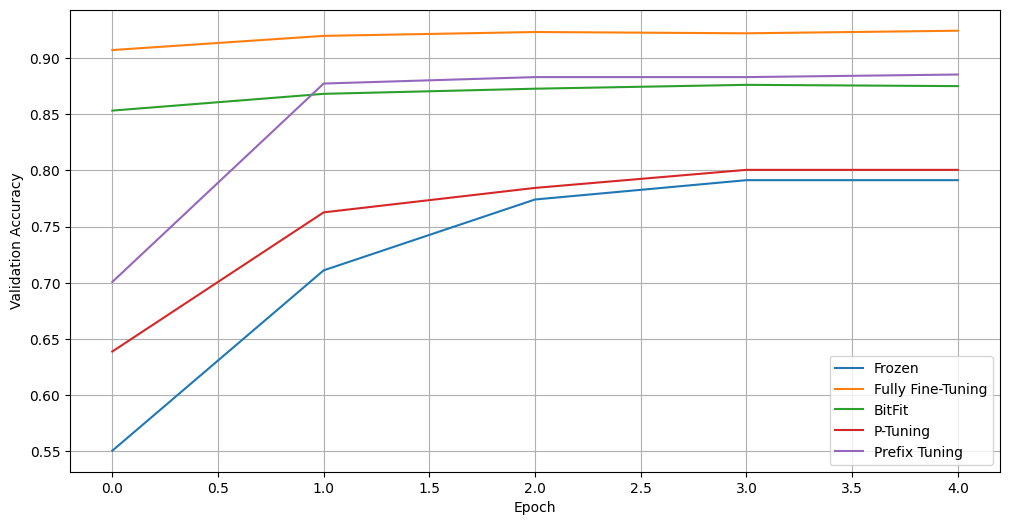

In [43]:
plot_training_record(training_record, metric_name="val_acc")

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer


# 打印模型结构（比如打印nn.Module）时，展示的子模块顺序通常是它们在__init__中被赋值为self.xxx属性的顺序（即注册到模块中的顺序）。
# 但注意，如果模块是放在nn.Sequential、nn.ModuleList或nn.ModuleDict等容器里的，则显示它们内部的顺序。
# 总体而言，pytorch的模型结构展示顺序和你在__init__赋值顺序是一致的，符合python的属性注册先后顺序。

class PTuningV2Bert(nn.Module):
    def __init__(self, num_virtual_tokens=20, prefix_projection=True):
        super().__init__()
        # 加载预训练的BERT模型，用于编码输入序列
        self.model = AutoModel.from_pretrained("bert-base-uncased")
        # 创建分类器，仅接收BERT的[CLS]输出向量，输出为1个标量（适用于二分类任务）
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 冻结BERT的所有参数，使得只训练自定义参数和分类头，节省显存和训练开销
        for param in self.model.parameters():
            param.requires_grad = False

        # 保存前缀相关的参数设置
        self.num_virtual_tokens = num_virtual_tokens  # 前缀token（虚拟token）数量
        self.prefix_projection = prefix_projection    # 是否启用前缀投影MLP
        hidden_size = self.model.config.hidden_size   # 隐藏层维度（BERT默认768）
        self.num_layers = self.model.config.num_hidden_layers  # Transformer层数（BERT默认12层）
        self.num_attention_heads = self.model.config.num_attention_heads  # 注意力头数（BERT默认12）
        self.embed_size_per_head = hidden_size // self.num_attention_heads  # 每个注意力头分配的维度（768//12=64）

        # 前缀token的嵌入矩阵，将每个虚拟token映射为一个hidden_size维度的向量
        self.prefix_embeddings = nn.Embedding(self.num_virtual_tokens, hidden_size)
        # 对前缀embedding权重初始化为均匀分布
        nn.init.uniform_(self.prefix_embeddings.weight, -0.1, 0.1)

        if self.prefix_projection:
            # 定义两层MLP（含tanh激活）以对前缀嵌入向量进行投影
            # 输出维度为每层每头的key+value（2*hidden_size），共num_layers层
            self.prefix_projection_layer = nn.Sequential(
                nn.Linear(hidden_size, hidden_size),   # 投影到hidden_size
                nn.Tanh(),                             # 非线性变换
                nn.Linear(hidden_size, self.num_layers * 2 * hidden_size)  # 输出: 每层的key/value
            )

    def forward(self, input_ids, attention_mask, **args):
        # input_ids: [batch_size, seq_len]
        # attention_mask: [batch_size, seq_len]
        batch_size = input_ids.size(0)

        # 构造shape为[batch_size, num_virtual_tokens]的前缀token索引（每个样本都一样）
        prefix_tokens = torch.arange(self.num_virtual_tokens, device=input_ids.device).unsqueeze(0).expand(batch_size, -1)
        # 得到前缀token的嵌入：[batch_size, num_virtual_tokens, hidden_size]
        prefix_embeddings = self.prefix_embeddings(prefix_tokens)

        if self.prefix_projection:
            # 前缀嵌入经过MLP投影
            # 输出shape：[batch_size, num_virtual_tokens, num_layers * 2 * hidden_size]
            past_key_values = self.prefix_projection_layer(prefix_embeddings)
        else:
            # 不用MLP投影，直接用嵌入
            past_key_values = prefix_embeddings

        # 将past_key_values reshape为Transformer要求的格式
        # [batch, num_virtual_tokens, num_layers*2*hidden_size] ->
        # [batch_size, num_layers, 2, num_attention_heads, num_virtual_tokens, embed_size_per_head]
        past_key_values = past_key_values.view(
            batch_size, 
            self.num_layers,      # 层数
            2,                    # key和value
            self.num_attention_heads,                  # 头数
            -1,                   # num_virtual_tokens
            self.embed_size_per_head                   # 每头维度
        )
        # permute后得到:
        # [2, num_layers, batch, num_attention_heads, num_virtual_tokens, embed_size_per_head]
        past_key_values = past_key_values.permute(2, 1, 0, 3, 4, 5)
        # 按层分组，tuple长度为num_layers，每元素为(key, value)两tuple
        # 每个key和value的shape: [batch, num_attention_heads, num_virtual_tokens, embed_size_per_head]
        past_key_values = tuple([
            tuple([past_key_values[0][i], past_key_values[1][i]])  # (key, value)
            for i in range(self.num_layers)
        ])

        # 拼接注意力掩码：前缀token部分全为1（可见）
        # extended_attention_mask: [batch_size, num_virtual_tokens + seq_len]
        extended_attention_mask = torch.cat([
            torch.ones(batch_size, self.num_virtual_tokens, device=attention_mask.device),  # 前缀的attention mask
            attention_mask
        ], dim=1)

        # 调用BERT的forward，并传递p-tuning的past_key_values和新的attention_mask
        outputs = self.model(
            input_ids, 
            attention_mask=extended_attention_mask, 
            past_key_values=past_key_values
        )

        # 取[CLS]位的hidden state作为序列特征表示（BERT约定CLS做单句/分类任务用）
        feature = outputs.last_hidden_state[:, 0, :]  # shape: [batch_size, hidden_size]

        # 分类头，把CLS向量变成一个logit
        logits = self.classifier(feature)

        # 返回Sigmoid激活后结果，用于二分类
        return torch.sigmoid(logits).squeeze()

# 创建P-Tuning v2 BERT模型实例
p_tuning_v2_bert = PTuningV2Bert()
print(p_tuning_v2_bert)

# 计算模型可学习参数量（只统计可训练参数，主要包括prefix和分类头）
print(f'Total trainable parameters: {count_parameters(p_tuning_v2_bert)}')

# 执行训练，记录训练过程（训练函数需提前定义）
training_record["P-Tuning v2"] = train(
    p_tuning_v2_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience
)


PTuningV2Bert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6768, train_acc 0.5628, val_loss 0.6418, val_acc 0.5883


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.3633, train_acc 0.8477, val_loss 0.3096, val_acc 0.8750


...

epoch 2: train_loss 0.3030, train_acc 0.8725, val_loss 0.2949, val_acc 0.8739


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.2915, train_acc 0.8780, val_loss 0.2884, val_acc 0.8853


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.2883, train_acc 0.8787, val_loss 0.2866, val_acc 0.8830


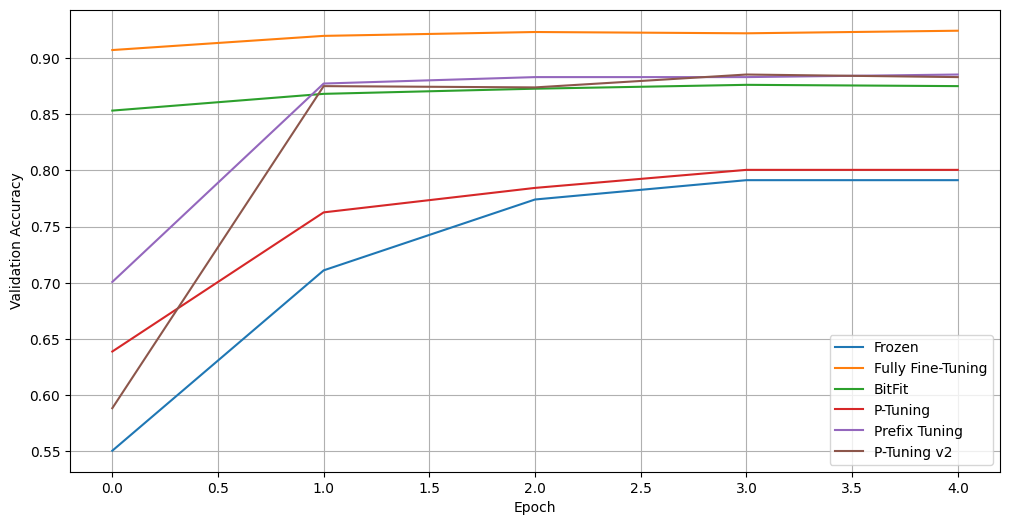

In [45]:
plot_training_record(training_record, metric_name="val_acc")

## LoRA

LoRA（论文：LoRA: LOW-RANK ADAPTATION OF LARGE LANGUAGE MODELS），该方法的核心思想就是通过低秩分解来模拟参数的改变量，从而以极小的参数量来实现大模型的间接训练。

在涉及到矩阵相乘的模块，在原始的PLM旁边增加一个新的通路，通过前后两个矩阵A,B相乘，第一个矩阵A负责降维，第二个矩阵B负责升维，中间层维度为r，从而来模拟所谓的本征秩（intrinsic rank）。

rank的作用：
rank代表低秩矩阵的秩，即线性变换矩阵A和B的输出特征数量。在LoRA中，原始的高维特征通过线性变换A被映射到一个低维空间（rank维），然后再通过另一个线性变换B映射回原始特征空间。较低的rank值意味着更少的参数需要更新，从而降低了模型复杂度和计算成本。

lora_alpha的作用：
lora_alpha是一个缩放因子，用于调整LoRA输出的贡献。它通过除以rank来计算得到scaling，这个缩放因子被用于控制低秩空间中的特征对最终输出的贡献度。较大的lora_alpha值会增加LoRA特征的影响力，而较小的值则会减少其影响。

In [46]:
for layer in bert_model.encoder.layer:
  print(type(layer))
  print('-'*50)

<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'transformers.models.bert.modeling_bert.BertLayer'>
--------------------------------------------------
<class 'tr

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel
# 此处省略了训练用的优化器、损失函数等其它必要的导入

# 定义LoRALayer类，实现LoRA机制的核心模块，用于替换原有线性层
class LoRALayer(nn.Module):
    def __init__(self, module: nn.Module, rank: int = 1, lora_alpha: int = 1):
        """
        参数说明:
        module: nn.Module
            要注入LoRA机制的原始线性层，如BertSelfAttention中的query或key投影层。
        rank: int
            LoRA中的低秩矩阵秩，将输入特征从高维压缩到低维再升回高维，rank越小参数量越少。默认1（实际应大于1）。
        lora_alpha: int
            LoRA输出的缩放系数，用于控制LoRA分支输出的幅度。
        """
        super().__init__()
        # 检查rank大于1且为正整数
        assert isinstance(rank, int) and rank > 1, "Lora rank should be a positive integer"
        
        # 计算LoRA分支的缩放系数，影响其对最终结果的贡献
        self.scaling = lora_alpha / rank
        # 保存被注入LoRA的原始层
        self.module = module
        
        # 构造A、B两个低秩线性层：
        # A: 输入特征 → rank（降维）
        # B: rank → 输出特征（升维）
        self.A = nn.Linear(module.in_features, rank, bias=False)
        self.B = nn.Linear(rank, module.out_features, bias=False)
        
        # 初始化A和B的权重
        # A用Kaiming均匀初始化，便于收敛；B全为0，确保LoRA分支初始化时不会影响主分支
        nn.init.kaiming_uniform_(self.A.weight, a=5 ** 0.5)
        nn.init.zeros_(self.B.weight)
        
        # 确保A、B与原层在同一设备
        self.A.to(device=module.weight.device)
        self.B.to(device=module.weight.device)

    def forward(self, inputs, *args, **kwargs):
        """
        前向传播。输出为原模块输出 + LoRA分支输出。
        - 原模块输出不参与梯度计算（torch.no_grad），仅更新LoRA新增参数
        """
        # 
        # inputs为输入到BERT等transformers线性层（如query、key投影）的一组张量，形状通常为[batch_size, seq_len, hidden_size]
        # 在LoRALayer中，inputs的最后一维等于原始线性层in_features
        # 例：对BERT自注意力query/key分支，inputs通常是encoder输出的context，形状[batch, seq_len, hidden_size]
        # self.A、self.B对最后一维做降维、升维；支持批量和序列输入
        # 下面获取原层输出（冻结其参数，不反向传播）
        with torch.no_grad():
            outputs = self.module(inputs, *args, **kwargs)
        # LoRA分支：A降维→B升维→缩放，最后与原输出累加
        lora_output = self.B(self.A(inputs)) * self.scaling
        return outputs + lora_output

# 定义LoRABert类，将LoRA注入到BERT模型自注意力层的Q和K分支
class LoRABert(nn.Module):
    def __init__(self, rank=8, lora_alpha=32):
        """
        参数说明:
        rank: int
            LoRA低秩矩阵的秩
        lora_alpha: int
            LoRA分支的缩放因子
        """
        super().__init__()
        # 加载预训练BERT模型（路径为bert-base-uncased）
        self.model = AutoModel.from_pretrained("root/bert-base-uncased")
        
        # 只在encoder各层的query/key引入LoRA（仅训练LoRA参数，主干全部冻结）
        self._apply_lora(rank=rank, lora_alpha=lora_alpha)
        
        # 定义简单线性分类头（输入为BERT输出的hidden_size，输出1维，适合二分类）
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

    def _apply_lora(self, rank, lora_alpha):
        """
        在BERT encoder各层的query和key上引入LoRA，并冻结原始参数。
        """
        # 冻结BERT全部原始参数
        for param in self.model.parameters():
            param.requires_grad = False

        # 遍历每个Transformer编码层
        for layer in self.model.encoder.layer.children():
            # 用LoRALayer替换attention.self.query和attention.self.key，只训练这两层新参数
            layer.attention.self.query = LoRALayer(layer.attention.self.query, rank=rank, lora_alpha=lora_alpha)
            layer.attention.self.key = LoRALayer(layer.attention.self.key, rank=rank, lora_alpha=lora_alpha)

    def forward(self, input_ids, attention_mask, token_type_ids):
        """
        前向传播流程
        1. 输入张量送入BERT得到输出
        2. 取last_hidden_state的[CLS]位（第0号token）特征向量
        3. 分类头得分，Sigmoid激活输出概率（适合二分类）
        """
        # 经过BERT主干，output.last_hidden_state形状：[batch_size, seq_len, hidden_size]
        outputs = self.model(input_ids, attention_mask, token_type_ids)
        # 取每个样本的第0个token（[CLS]位置）向量，[batch_size, hidden_size]
        feature = outputs.last_hidden_state[:, 0, :]
        # 分类头，输出logit
        logits = self.classifier(feature)
        # Sigmoid激活得到二分类概率，输出形状：[batch_size]
        return torch.sigmoid(logits).squeeze()

# 实例化LoRA-BERT模型，指定rank与lora_alpha两个核心超参数
lora_bert = LoRABert(rank=8, lora_alpha=32)
print(lora_bert)
# count_parameters为参数统计函数，输出可训练参数量
count_parameters(lora_bert)


LoRABert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): LoRALayer(
                (module): Linear(in_features=768, out_features=768, bias=True)
                (A): Linear(in_features=768, out_features=8, bias=False)
                (B): Linear(in_features=8, out_features=768, bias=False)
              )
              (key): LoRALayer(
                (module): Linear(in_features=768, out_features=768, bias=True)
                (A): Linear(in_features=768, out_features=8, bias=False)
                (B): 

In [48]:
# 假设train是一个函数，用于训练模型
# training_record是一个字典，用于记录不同模型的训练结果
# train_loader和val_loader是数据加载器，device是指定的设备（CPU或GPU）
# num_epochs是训练的轮数，patience是早停的耐心轮数
training_record["LoRA"] = train(lora_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience)

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6594, train_acc 0.6123, val_loss 0.4899, val_acc 0.8532


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.3933, train_acc 0.8461, val_loss 0.3044, val_acc 0.8761


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 2: train_loss 0.3226, train_acc 0.8657, val_loss 0.2833, val_acc 0.8876


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.3076, train_acc 0.8729, val_loss 0.2764, val_acc 0.8899


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.3035, train_acc 0.8742, val_loss 0.2752, val_acc 0.8911


In [49]:
del lora_bert

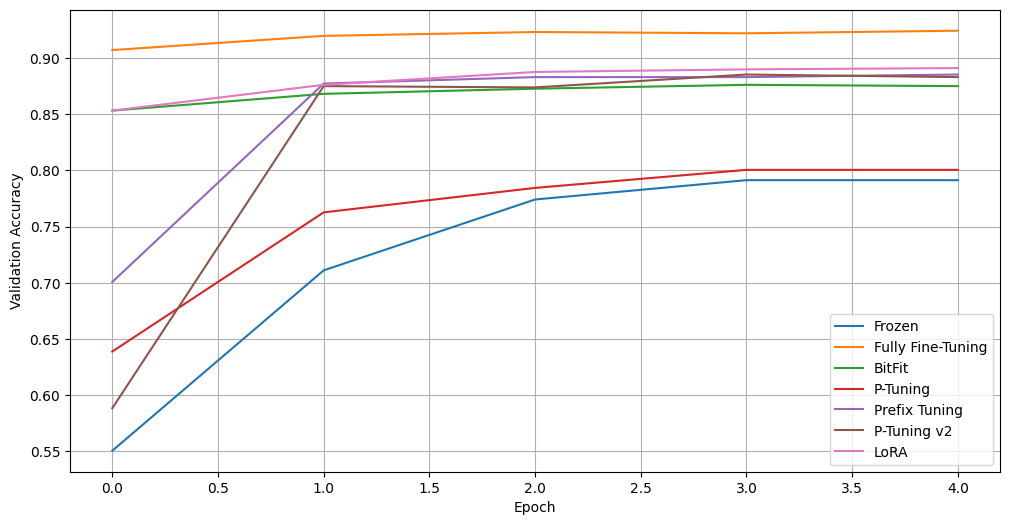

In [50]:
plot_training_record(training_record, metric_name="val_acc")

## Adapter Tuning

Adapter Tuning（论文：Parameter-Efficient Transfer Learning for NLP），该方法设计了Adapter结构，并将其嵌入Transformer的结构里面，针对每一个Transformer层，增加了两个Adapter结构(分别是多头注意力的投影之后和第二个feed-forward层之后)，在训练时，固定住原来预训练模型的参数不变，只对新增的 Adapter 结构和 Layer Norm 层进行微调，从而保证了训练的高效性。

In [ ]:
class AdapterLayer(nn.Module):
    def __init__(self, input_size, adapter_size):
        """
        适配器层（Adapter Layer），包含降维-非线性-升维流程。
        - input_size: 输入特征维度（如BERT隐藏层大小）
        - adapter_size: 降低到的瓶颈维度（低秩结构）
        """
        super().__init__()
        # 将输入特征从 input_size 映射降维到 adapter_size
        self.down_project = nn.Linear(input_size, adapter_size)
        # 非线性激活，增加模型表达力
        self.nolinearity = nn.ReLU()
        # 从 adapter_size 升维回 input_size
        self.up_project = nn.Linear(adapter_size, input_size)

    def forward(self, x):
        """
        前向传播流程：
        1. 先降维（down_project）
        2. 非线性激活（ReLU）
        3. 升维还原（up_project）
        结果与输入维度保持一致，方便与残差结构相加
        """
        return self.up_project(self.nolinearity(self.down_project(x)))


class BertSelfOutput(nn.Module):
    """
    重写BERT原始自注意力块的输出模块（BertSelfOutput），
    插入Adapter以实现高效参数微调。
    """
    def __init__(self, config, adapter_size):
        """
        - config: 预训练模型的配置对象
        - adapter_size: 适配器的瓶颈层维度
        """
        super().__init__()
        # 原始输出 dense 全连接层
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)
        # 原始的LayerNorm层归一化，防止梯度发散，提升收敛速度
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        # 原始Dropout，防止过拟合
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        # 适配器结构插入
        self.adapter = AdapterLayer(config.hidden_size, adapter_size)

    def forward(self, hidden_states: torch.Tensor, input_tensor: torch.Tensor) -> torch.Tensor:
        """
        前向传播流程：
        1. dense线性投影
        2. dropout（防止过拟合）
        3. 通过适配器
        4. 与输入残差相加并归一化
        """
        hidden_states = self.dense(hidden_states)
        hidden_states = self.dropout(hidden_states)
        hidden_states = self.adapter(hidden_states)  # 经Adapter以微调极少参数
        hidden_states = self.LayerNorm(hidden_states + input_tensor)  # 残差+归一化
        return hidden_states

class BertOutput(nn.Module):
    """
    重写BERT块中的输出模块（BertOutput），同样插入Adapter结构。
    """
    def __init__(self, config, adapter_size):
        """
        - config: BERT模型配置
        - adapter_size: 适配器瓶颈层的维度
        """
        super().__init__()
        # Feedforward输出的全连接层（由高维还原为hidden_size维）
        self.dense = nn.Linear(config.intermediate_size, config.hidden_size)
        # 层归一化
        self.LayerNorm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        # dropout
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        # 适配器层插入
        self.adapter = AdapterLayer(config.hidden_size, adapter_size)

    def forward(self, hidden_states: torch.Tensor, input_tensor: torch.Tensor) -> torch.Tensor:
        """
        前向传播同理：
        1. dense
        2. dropout
        3. adapter微调部分
        4. 残差+归一化
        """
        hidden_states = self.dense(hidden_states)
        hidden_states = self.dropout(hidden_states)
        hidden_states = self.adapter(hidden_states)
        hidden_states = self.LayerNorm(hidden_states + input_tensor)
        return hidden_states


class AdapterBert(nn.Module):
    """
    Adapter Tuning版BERT模型，冻结大部分参数，只训练额外注入的Adapter以及分类头。
    """
    def __init__(self, adapter_size=64):
        """
        - adapter_size: Adapter瓶颈层维度，越小可训练参数越少
        """
        super().__init__()
        # 加载预训练BERT模型
        self.model = AutoModel.from_pretrained("root/bert-base-uncased")
        # 获取原始BERT参数快照（后续载入新参数用），
        # 因为下面要用自定义BertSelfOutput和BertOutput覆盖原模型结构
        pretrained_state_dict = self.model.state_dict()
        print(self.model.config)
        # 句向量分类头，输出1个logit用于二分类
        self.classifier = nn.Linear(self.model.config.hidden_size, 1)

        # 用适配器层覆盖BERT模型每层的关键模块（共12层，每层都加适配器）
        self._apply_adapter(adapter_size=adapter_size)

        # 将适配器参数手动加入state_dict（覆盖后才有adapter参数出现）
        for name, param in self.model.named_parameters():
            if "adapter" in name:
                pretrained_state_dict[name] = param  # 添加adapter自定义层的参数
        # 更新模型权重
        self.model.load_state_dict(pretrained_state_dict)

        # 冻结除了适配器adapter相关以外的所有参数，只训练Adapter和（后面定义的）分类头
        for name, param in self.model.named_parameters():
            if "adapter" not in name:
                param.requires_grad = False

        # 删除暂存的权重释放显存
        del pretrained_state_dict

    def _apply_adapter(self, adapter_size):
        """
        遍历BERT每个encoder层，将attention.output和output
        替换为自定义带adapter的模块，实现adapter插拔式注入。
        """
        for layer in self.model.encoder.layer:
            # 覆盖自注意力输出
            layer.attention.output = BertSelfOutput(self.model.config, adapter_size)
            # 覆盖输出层
            layer.output = BertOutput(self.model.config, adapter_size)

    def forward(self, input_ids, attention_mask, token_type_ids):
        """
        BERT前向推理流程：
        1. 输入批量token
        2. BERT主干（含adapter）获得所有token表示
        3. 只取[CLS]位张量，做分类
        4. 分类头输出logit，Sigmoid概率化
        """
        # BERT主干前向
        outputs = self.model(input_ids, attention_mask, token_type_ids)
        # [CLS]特征抽取：batch第0号token（句向量），shape: [batch_size, hidden_size]
        feature = outputs.last_hidden_state[:, 0, :]
        # 分类
        logits = self.classifier(feature)
        # 二分类Sigmoid激活（输出概率）
        return torch.sigmoid(logits).squeeze()


# 实例化adapter注入后的BERT，只引入极少adapter参数微调
adapter_bert = AdapterBert(adapter_size=64)
print('-'*50)
print(adapter_bert)
print('-'*50)
# 输出参数量信息，辅助观测参数量缩减效果
count_parameters(adapter_bert)


BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "torch_dtype": "float32",
  "transformers_version": "4.53.2",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

--------------------------------------------------
AdapterBert(
  (model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (drop

In [52]:
# 训练模型
training_record["Adapter Tuning"] = train(adapter_bert, train_loader, val_loader, device, num_epochs=num_epochs, patience=patience)

  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 0: train_loss 0.6252, train_acc 0.6185, val_loss 0.4753, val_acc 0.7833


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 1: train_loss 0.3828, train_acc 0.8296, val_loss 0.4225, val_acc 0.7982


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 2: train_loss 0.3487, train_acc 0.8473, val_loss 0.4030, val_acc 0.8085


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 3: train_loss 0.3332, train_acc 0.8556, val_loss 0.3985, val_acc 0.8073


  0%|          | 0/2105 [00:00<?, ?it/s]

epoch 4: train_loss 0.3291, train_acc 0.8586, val_loss 0.3978, val_acc 0.8096


In [53]:
del adapter_bert

## Plot

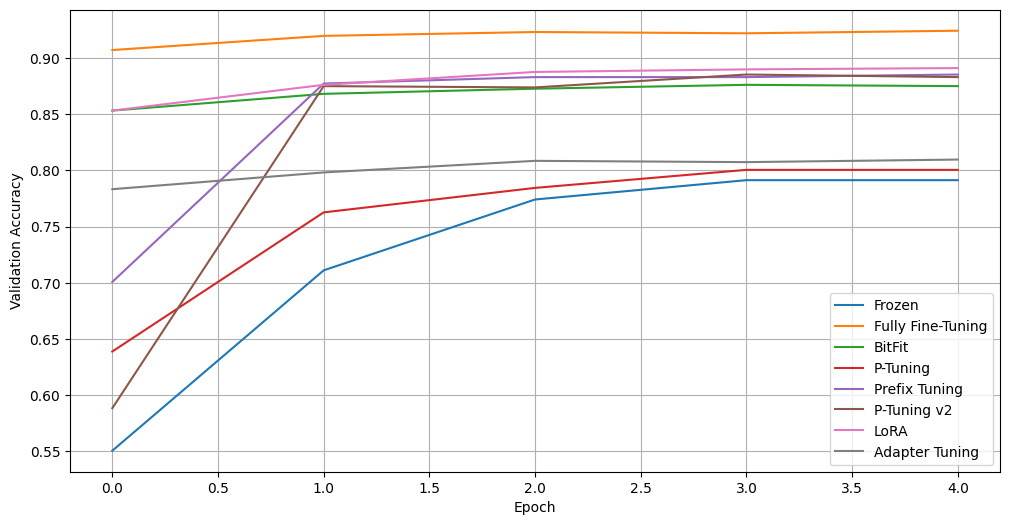

In [54]:

plot_training_record(training_record, metric_name="val_acc")